# Imports

In [2]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import cupy as cp
import seaborn as sns
from __future__ import annotations

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin


from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.naive_bayes import GaussianNB



In [14]:
with open("scores_decoding_v2.pkl", "rb") as f:
    res = pickle.load(f)
times = res['times'] - 0.2
del res['times']

In [15]:
times

array([-2.00000000e+00, -1.99000000e+00, -1.98000000e+00, -1.97000000e+00,
       -1.96000000e+00, -1.95000000e+00, -1.94000000e+00, -1.93000000e+00,
       -1.92000000e+00, -1.91000000e+00, -1.90000000e+00, -1.89000000e+00,
       -1.88000000e+00, -1.87000000e+00, -1.86000000e+00, -1.85000000e+00,
       -1.84000000e+00, -1.83000000e+00, -1.82000000e+00, -1.81000000e+00,
       -1.80000000e+00, -1.79000000e+00, -1.78000000e+00, -1.77000000e+00,
       -1.76000000e+00, -1.75000000e+00, -1.74000000e+00, -1.73000000e+00,
       -1.72000000e+00, -1.71000000e+00, -1.70000000e+00, -1.69000000e+00,
       -1.68000000e+00, -1.67000000e+00, -1.66000000e+00, -1.65000000e+00,
       -1.64000000e+00, -1.63000000e+00, -1.62000000e+00, -1.61000000e+00,
       -1.60000000e+00, -1.59000000e+00, -1.58000000e+00, -1.57000000e+00,
       -1.56000000e+00, -1.55000000e+00, -1.54000000e+00, -1.53000000e+00,
       -1.52000000e+00, -1.51000000e+00, -1.50000000e+00, -1.49000000e+00,
       -1.48000000e+00, -

(<matplotlib.lines.Line2D at 0x7aa48cbc40e0>,
 <matplotlib.collections.FillBetweenPolyCollection at 0x7aa48cbc4320>)

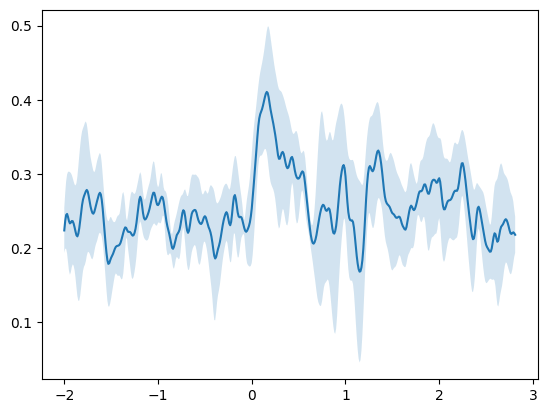

In [16]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, times, res['left_elbow']['MOp'])


In [46]:
baseline = (-1.5, -0.5)
bmask = (times >= baseline[0]) & (times <= baseline[1])

perturb = (0, 1)
pmask = (times >= perturb[0]) & (times <= perturb[1])


In [171]:
key='left_foot'

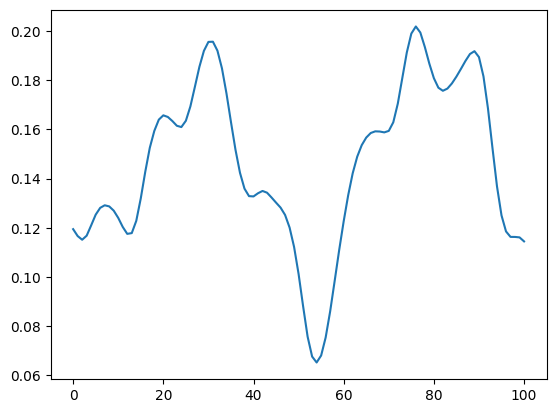

In [172]:
plt.plot(res[key][area][pmask].mean(axis=-1))

In [48]:
# baseline, perturb = (-1.9, -0.2), (0.1, 1.5)
# bmask = (times >= baseline[0]) & (times <= baseline[1])
# pmask = (times >= perturb[0]) & (times <= perturb[1])

baseline_scores = {}
sd_baseline = {}
peak_scores = {}
bl_zscore = {}
areas = ['MOp', 'SSp', 'CP', 'VAL']
for key in res.keys():
    peak_scores[key] = {}
    baseline_scores[key] = {}
    sd_baseline[key] = {}
    bl_zscore[key] = {}

    for area in areas:
        peak_scores[key][area] = np.max(res[key][area][pmask].mean(axis=-1))
        baseline_scores[key][area] = res[key][area][bmask].mean(axis=-1).mean()
        sd_baseline[key][area] = res[key][area][bmask].mean(axis=-1).std()
        bl_zscore[key][area] = (peak_scores[key][area] - baseline_scores[key][area]) / sd_baseline[key][area]

In [20]:
# Manually written output of res.keys(), vertical list
KEYPOINTS = [
    'left_ankle',
    'left_elbow',
    'left_foot',
    'left_knee',
    'left_paw',
    'left_shoulder',
    'left_wrist',
    'right_ankle',
    'right_elbow',
    'right_foot',
    'right_knee',
    'right_paw',
    'right_shoulder',
    'right_wrist',
    'shoulder_center',
    'tail_base',
    'tail_middle',
    'tail_tip',
    'hip_center',
    # 'left_forelimb',
    # 'right_forelimb',
    # 'left_hindlimb',
    # 'right_hindlimb',
    # 'forelimbs',
    # 'hindlimbs',
    # 'tail',
    # 'all'
]

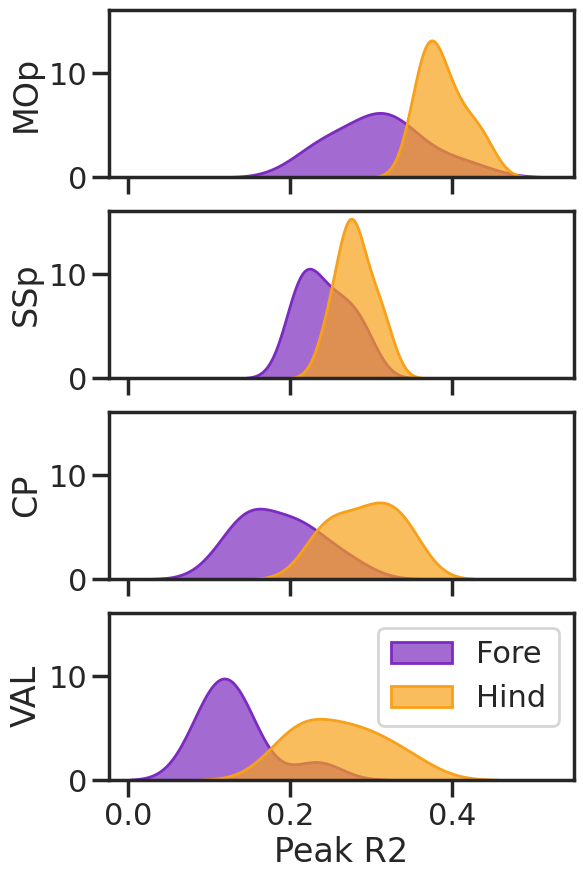

<Figure size 640x480 with 0 Axes>

In [21]:
# Plot histogram of peak scores for each area, colored by fore/hind
import seaborn as sns

# Define forelimb and hindlimb keypoints
FORELIMB_KEYS = [
    'left_shoulder', 'left_elbow', 'left_wrist', 'left_paw',
    'right_shoulder', 'right_elbow', 'right_wrist', 'right_paw'
]
HINDLIMB_KEYS = [
    'left_ankle', 'left_knee', 'left_foot',
    'right_ankle', 'right_knee', 'right_foot'
]

# Colors to match the attached image
fore_color = '#7c2bc0'  # purple
hind_color = '#f7a11a'  # orange

areas = ['MOp', 'SSp', 'CP', 'VAL']

with vizutils.apply_plot_style('poster'):
    fig, axes = plt.subplots(len(areas), 1, figsize=(6, 10), sharey=True, sharex=True)
    for i, area in enumerate(areas):
        # Gather peak scores for each group
        fore_scores = [peak_scores[k][area] for k in FORELIMB_KEYS if k in peak_scores]
        hind_scores = [peak_scores[k][area] for k in HINDLIMB_KEYS if k in peak_scores]
        # Plot distributions
        sns.kdeplot(fore_scores, ax=axes[i], color=fore_color, fill=True, label='Fore', linewidth=2, alpha=0.7)
        sns.kdeplot(hind_scores, ax=axes[i], color=hind_color, fill=True, label='Hind', linewidth=2, alpha=0.7)
        axes[i].set_ylabel(f'{area}')
        # axes[i].set_xticklabels([])
    # plt.tight_layout()
    axes[-1].legend()
    axes[-1].set_xlabel('Peak R2')
    plt.show()

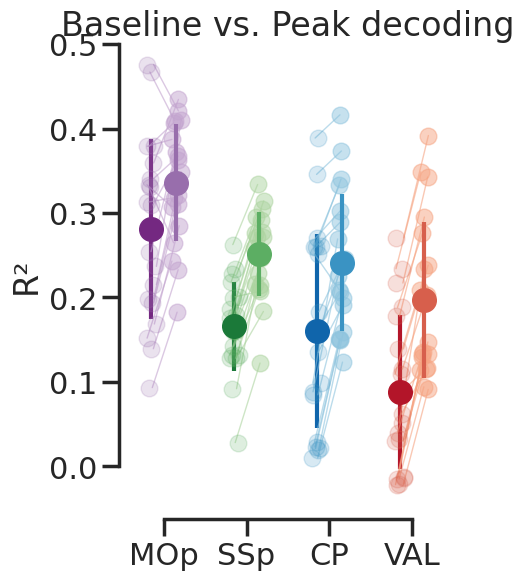

In [31]:
alpha = 0.3
areas = ['MOp', 'SSp', 'CP', 'VAL']
with vizutils.apply_plot_style('poster'):
    fig, ax = plt.subplots(figsize=(4, 6))

    for area in areas:
        # --- BASELINE SCORES ---
        jitters = []
        for keypoint in KEYPOINTS:
            jitter_ = np.random.uniform(-0.06, 0.06)
            x_base = areas.index(area) + jitter_
            y_base = baseline_scores[keypoint][area]
            ax.errorbar(x_base, y_base, fmt='o', color=getattr(colors, f"{area}_light"), alpha=0.2)
            jitters.append(jitter_)

        mean_ = np.array([baseline_scores[k][area] for k in KEYPOINTS])
        ax.errorbar(
            areas.index(area),
            mean_.mean(),
            fmt='o',
            color=getattr(colors, f"{area}"),
            markersize=17,
            yerr=mean_.std()
        )

        # --- PEAK SCORES ---
        for keypoint in KEYPOINTS:
            jitter = np.random.uniform(-0.06, 0.06)
            x_peak = areas.index(area) + 0.3 + jitter
            y_peak = peak_scores[keypoint][area]
            ax.errorbar(x_peak, y_peak, fmt='o', color=getattr(colors, f"{area}_light_light"), alpha=0.5)

            # --- CONNECTING LINE ---
            ax.plot(
                [areas.index(area) + jitter, areas.index(area) + 0.3 + jitter],
                [baseline_scores[keypoint][area], peak_scores[keypoint][area]],
                color=getattr(colors, f"{area}_light_light"),
                alpha=0.6,
                linewidth=1
            )

        mean_ = np.array([peak_scores[k][area] for k in KEYPOINTS])
        ax.errorbar(
            areas.index(area) + 0.3,
            mean_.mean(),
            fmt='o',
            color=getattr(colors, f"{area}_light"),
            markersize=17,
            yerr=mean_.std(),
            zorder=100
        )

    ax.set_ylabel('R²')

    # --- Add area names as x-tick labels ---
    ax.set_xticks([i + 0.15 for i in range(len(areas))])  # centre tick between baseline and peak
    ax.set_xticklabels(areas, rotation=45, ha='right')
    ax.set_title('Baseline vs. Peak decoding')
    # ax.set_ylim(0, 0.4)
plt.show()


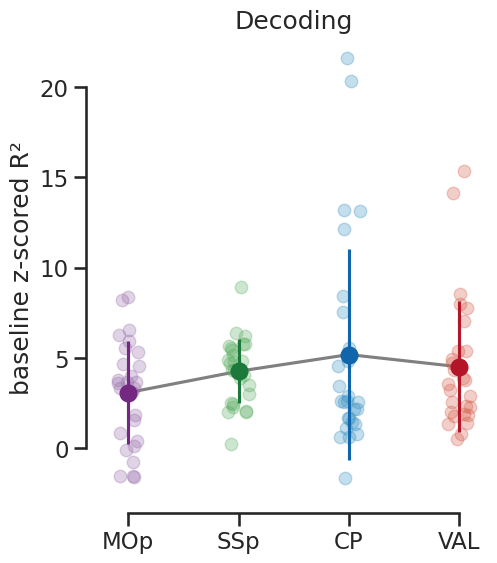

In [32]:
with vizutils.apply_plot_style():
    fig, ax = plt.subplots(figsize=(5, 6), sharey='all')

    mean_points = []  # to store mean values for connecting later

    for area in areas:
        # individual points
        for keypoint in peak_scores.keys():
            jitter = np.random.uniform(-0.1, 0.1)
            ax.errorbar(
                areas.index(area) + jitter,
                (peak_scores[keypoint][area] - baseline_scores[keypoint][area]) / sd_baseline[keypoint][area],
                fmt='o',
                color=getattr(colors, f"{area}_light"),
                alpha=0.3
            )

        # mean ± std
        mean_ = np.array([(peak_scores[k][area] - baseline_scores[k][area]) / sd_baseline[k][area] for k in peak_scores.keys()])
        m, s = mean_.mean(), mean_.std()
        ax.errorbar(
            areas.index(area),
            m,
            fmt='o',
            color=getattr(colors, f"{area}"),
            markersize=12,
            yerr=s,
            zorder=3
        )

        mean_points.append(m)

    # connect mean dots with a line
    ax.plot(range(len(areas)), mean_points, color='grey', linestyle='-', zorder=2)

    ax.set_title('Decoding')
    # ax.set_ylim(0, 26)
    ax.set_ylabel('baseline z-scored R²')
    ax.set_xticks(range(len(areas)))
    ax.set_xticklabels(areas)

plt.show()


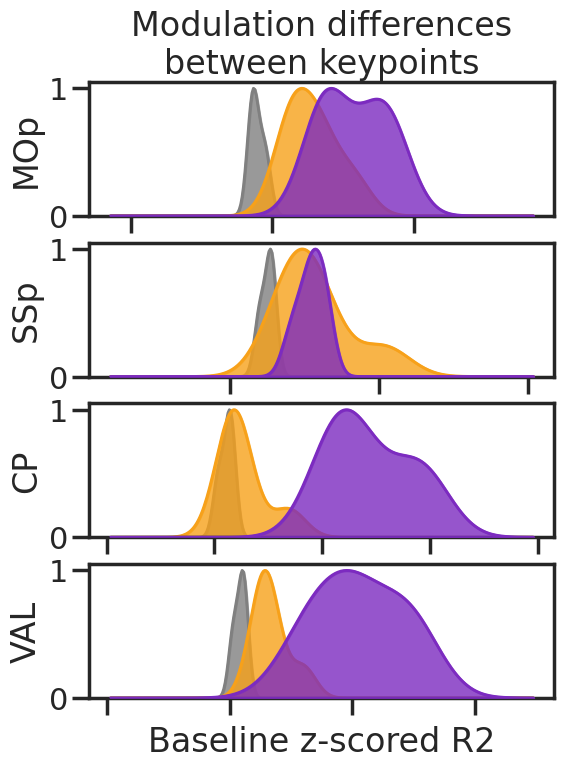

<Figure size 640x480 with 0 Axes>

In [49]:
# Plot histogram of normalized (z-scored) peak scores for each area, colored by fore/hind/tail, each normalized to its peak
import seaborn as sns
from scipy.stats import gaussian_kde
import numpy as np

# Define keypoint groups
FORELIMB_KEYS = [
    'left_elbow', 'left_wrist', 'left_paw',
    'right_elbow', 'right_wrist', 'right_paw'
]
HINDLIMB_KEYS = [
    'left_ankle', 'left_knee', 'left_foot',
    'right_ankle', 'right_knee', 'right_foot',
]
TAIL_KEYS = ['tail_base', 'tail_middle', 'tail_tip']

# Colors
fore_color = '#7c2bc0'  # purple
hind_color = '#f7a11a'  # orange
tail_color = 'gray'

areas = ['MOp', 'SSp', 'CP', 'VAL']

with vizutils.apply_plot_style('poster'):
    fig, axes = plt.subplots(len(areas), 1, figsize=(6, 8), sharey=True, sharex='none')
    for i, area in enumerate(areas):
        # Gather normalized (z-scored) peak scores for each group
        fore_scores = np.array([bl_zscore[k][area] for k in FORELIMB_KEYS if k in bl_zscore])
        hind_scores = np.array([bl_zscore[k][area] for k in HINDLIMB_KEYS if k in bl_zscore])
        tail_scores = np.array([bl_zscore[k][area] for k in TAIL_KEYS if k in bl_zscore])
        # Define x grid based on all scores, with margin
        all_scores = np.concatenate([fore_scores, hind_scores, tail_scores])
        x_min = all_scores.min() - 10
        x_max = all_scores.max() + 10
        x_grid = np.linspace(x_min, x_max, 300)
        # KDE and normalize to peak, plot in order: tail, hind, fore
        for scores, color, label, alpha, z in [
            (tail_scores, tail_color, 'Tail', 0.8, 1),
            (hind_scores, hind_color, 'Hind', 0.8, 2),
            (fore_scores, fore_color, 'Fore', 0.8, 3)
        ]:
            if len(scores) > 1:
                kde = gaussian_kde(scores)
                y = kde(x_grid)
                y_norm = y / y.max() if y.max() > 0 else y
                axes[i].plot(x_grid, y_norm, color=color, label=label, linewidth=2, zorder=z)
                axes[i].fill_between(x_grid, 0, y_norm, color=color, alpha=alpha, zorder=z)
        axes[i].set_ylabel(f'{area}')
        axes[i].set_ylim(0, 1.05)
        axes[i].set_xticklabels([])

        # Set xlim to cover the full range of the KDE, with a margin
        # axes[i].set_xlim(-0.5, 0.5)
    axes[-1].set_xlabel('Baseline z-scored R2')
    axes[0].set_title('Modulation differences\nbetween keypoints')
    # plt.tight_layout()
    plt.show()

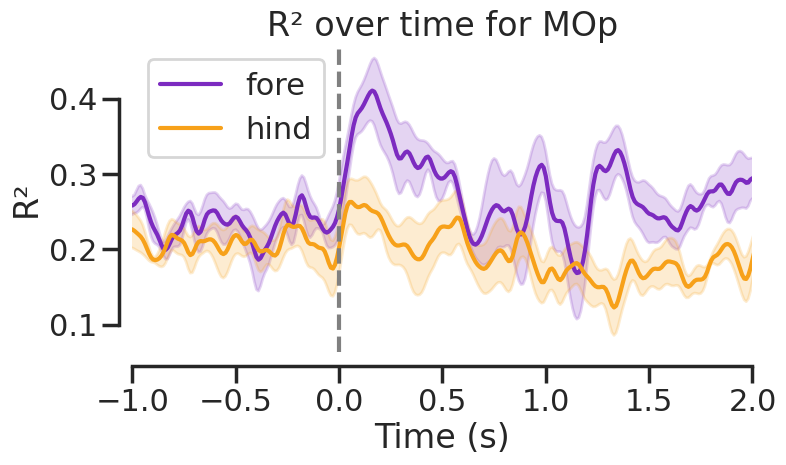

In [25]:
# Plot R² over time for a forelimb and hindlimb keypoint from MOp
forelimb_key = 'left_elbow'  # or any available forelimb keypoint
hindlimb_key = 'left_foot'  # or any available hindlimb keypoint

with vizutils.apply_plot_style('poster'):
    fig, ax = plt.subplots(figsize=(8, 4))
    vizutils.shaded_errorbar(ax, times, res[forelimb_key]['MOp'], errorStat=scipy.stats.sem, color=fore_color, label='fore')
    vizutils.shaded_errorbar(ax, times, res[hindlimb_key]['MOp']-0.1, errorStat=scipy.stats.sem, color=hind_color, label='hind')
    ax.axvline(0, color='gray', linestyle='dashed')

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('R²')
    ax.set_title('R² over time for MOp')
    ax.legend()
    ax.set_xlim(-1, 2)
plt.show()

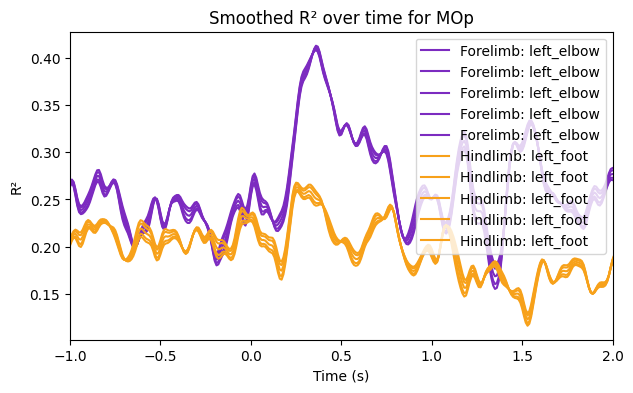

In [177]:
# Smooth and plot R² over time for a forelimb and hindlimb keypoint from MOp
from scipy.ndimage import gaussian_filter1d

forelimb_key = 'left_elbow'  # or any available forelimb keypoint
hindlimb_key = 'left_foot'  # or any available hindlimb keypoint

# Compute mean across trials
fore_curve = res[forelimb_key]['MOp']
hind_curve = res[hindlimb_key]['MOp']

# Smooth with a Gaussian filter (sigma in bins, e.g. 2-4 for mild smoothing)
sigma = 3
fore_curve_smooth = gaussian_filter1d(fore_curve, sigma=sigma)
hind_curve_smooth = gaussian_filter1d(hind_curve, sigma=sigma)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(times, fore_curve_smooth, label=f'Forelimb: {forelimb_key}', color=fore_color)
ax.plot(times, hind_curve_smooth-0.1, label=f'Hindlimb: {hindlimb_key}', color=hind_color)
ax.set_xlabel('Time (s)')
ax.set_ylabel('R²')
ax.set_title('Smoothed R² over time for MOp')
ax.set_xlim(-1, 2)
ax.legend()
plt.show()